In [1]:
#libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading datasets
base_path = "D:/DATA PROJECT/data"
gc_npz = os.path.join(base_path, "GoldCoast", "GoldCoast", 
                           "current_wind_20100101_20241231_GoaldCoast.npz")
sy_npz = os.path.join(base_path, "Sydney_NewCastle", "Sydney_NewCastle", 
                           "current_wind_20100101_20241231_Sydney.npz")


channel_names = ["U current", "V current", "Sea surface temp", 
                 "Salinity", "U wind", "V wind"]


gc_data = np.load(gc_npz)
sy_data = np.load(sy_npz)


gc_main = gc_data["UVTempSalt_UVTs"]  
sy_main = sy_data["UVTempSalt_UVTs"]

dates = pd.date_range("2010-01-01", "2024-12-31", freq="D")

sy = pd.read_csv(r"D:\DATA PROJECT\Sydney_stings.csv",
                 parse_dates=['time'], dayfirst=True)
gc = pd.read_csv(r"D:\DATA PROJECT\goaldcoast_stings.csv", 
                 parse_dates=['time'], dayfirst=True)

for df in (sy, gc):
    df['time'] = df['time'].dt.tz_localize(None)
    df['date'] = df['time'].dt.normalize()

sy['Region'] = 'Sydney'
gc['Region'] = 'Gold Coast'

stings = (pd.concat([sy, gc], ignore_index=True)
            .rename(columns={'Stings_sum':'stings_sum',
                             'Stings_binary':'stings_binary'})
            [['Region','date','stings_sum','stings_binary']])

In [3]:
# Checking grid size and valid ocean cells
# Mask is True where valid ocean data exist (not NaN for all time)

gc_mask = ~np.isnan(gc_main[:, 0, :, :]).all(axis=0)
sy_mask = ~np.isnan(sy_main[:, 0, :, :]).all(axis=0)

print("Gold Coast grid:", gc_mask.shape, "valid ocean cells:", gc_mask.sum())
print("Sydney grid:", sy_mask.shape, "valid ocean cells:", sy_mask.sum())


Gold Coast grid: (15, 15) valid ocean cells: 183
Sydney grid: (13, 13) valid ocean cells: 118


In [4]:
#converting masked 4D array (time, channel, H, W) into a dataframe with daily averages for each channel

def make_df(region_name, data, mask, dates, channels):
    T, C, H, W = data.shape
    rows = {}
    for i, chn in enumerate(channels):
        masked_vals = data[:, i, :, :][:, mask] #only take ocean cells
        daily_avg = np.nanmean(masked_vals, axis=1)
        rows[chn] = daily_avg
    df = pd.DataFrame(rows, index=dates)
    df.index.name = "Date"
    df["Region"] = region_name
    return df

gc_df = make_df("Gold Coast", gc_main, gc_mask, dates, channel_names)
sy_df = make_df("Sydney", sy_main, sy_mask, dates, channel_names)

all_df = pd.concat([gc_df, sy_df])
all_df.head(10)


,U current,V current,Sea surface temp,Salinity,U wind,V wind,Region
Date,,,,,,,
2010-01-01,-0.101543,-0.682206,25.984117,35.310858,-1.350650,-6.638138,Gold Coast
2010-01-02,-0.035152,-0.685357,25.928812,35.348238,1.565029,-8.252087,Gold Coast
2010-01-03,-0.230347,-0.546167,26.009888,35.358243,-3.923860,6.502674,Gold Coast
2010-01-04,-0.192440,-0.600306,25.745936,35.374060,-6.002225,6.037926,Gold Coast
2010-01-05,-0.178490,-0.552857,25.732278,35.371389,-5.123858,2.970986,Gold Coast
2010-01-06,-0.133753,-0.498218,25.921495,35.365305,-2.511772,-1.456332,Gold Coast
2010-01-07,-0.213470,-0.417091,26.086436,35.383106,-4.707287,0.398544,Gold Coast
2010-01-08,-0.211123,-0.367580,26.116103,35.388099,-5.255721,1.778475,Gold Coast
2010-01-09,-0.171594,-0.365517,26.233437,35.406379,-3.370998,-0.287061,Gold Coast


In [5]:
#statistical summary

summary = all_df.groupby("Region").agg(
    ["mean", "std", "min", "max"])
summary

U current                               V current            \
                mean       std       min       max      mean       std   
Region                                                                   
Gold Coast -0.008911  0.099859 -0.366549  0.411589 -0.366857  0.188741   
Sydney     -0.152917  0.168359 -0.713490  0.319542 -0.248096  0.237114   

                               Sea surface temp            ...   Salinity  \
                 min       max             mean       std  ...        min   
Region                                                     ...              
Gold Coast -1.084770  0.231902        24.025299  1.912614  ...  34.959118   
Sydney     -1.070762  0.417203        21.680250  2.138813  ...  35.133101   

                         U wind                                    V wind  \
                  max      mean       std        min        max      mean   
Region                                                                      
Gold Coast  35.836392 -1.358530  3.889554 -17.033267  12.591706  0.626570   
Sydney      35.819766 -0.161382  4.461667 -16.176857  16.230287  0.034393   

                                            
                 std        min        max  
Region                                      
Gold Coast  5.435193 -13.545776  17.736387  
Sydney      5.493073 -12.615044  17.403279  

[2 rows x 24 columns]

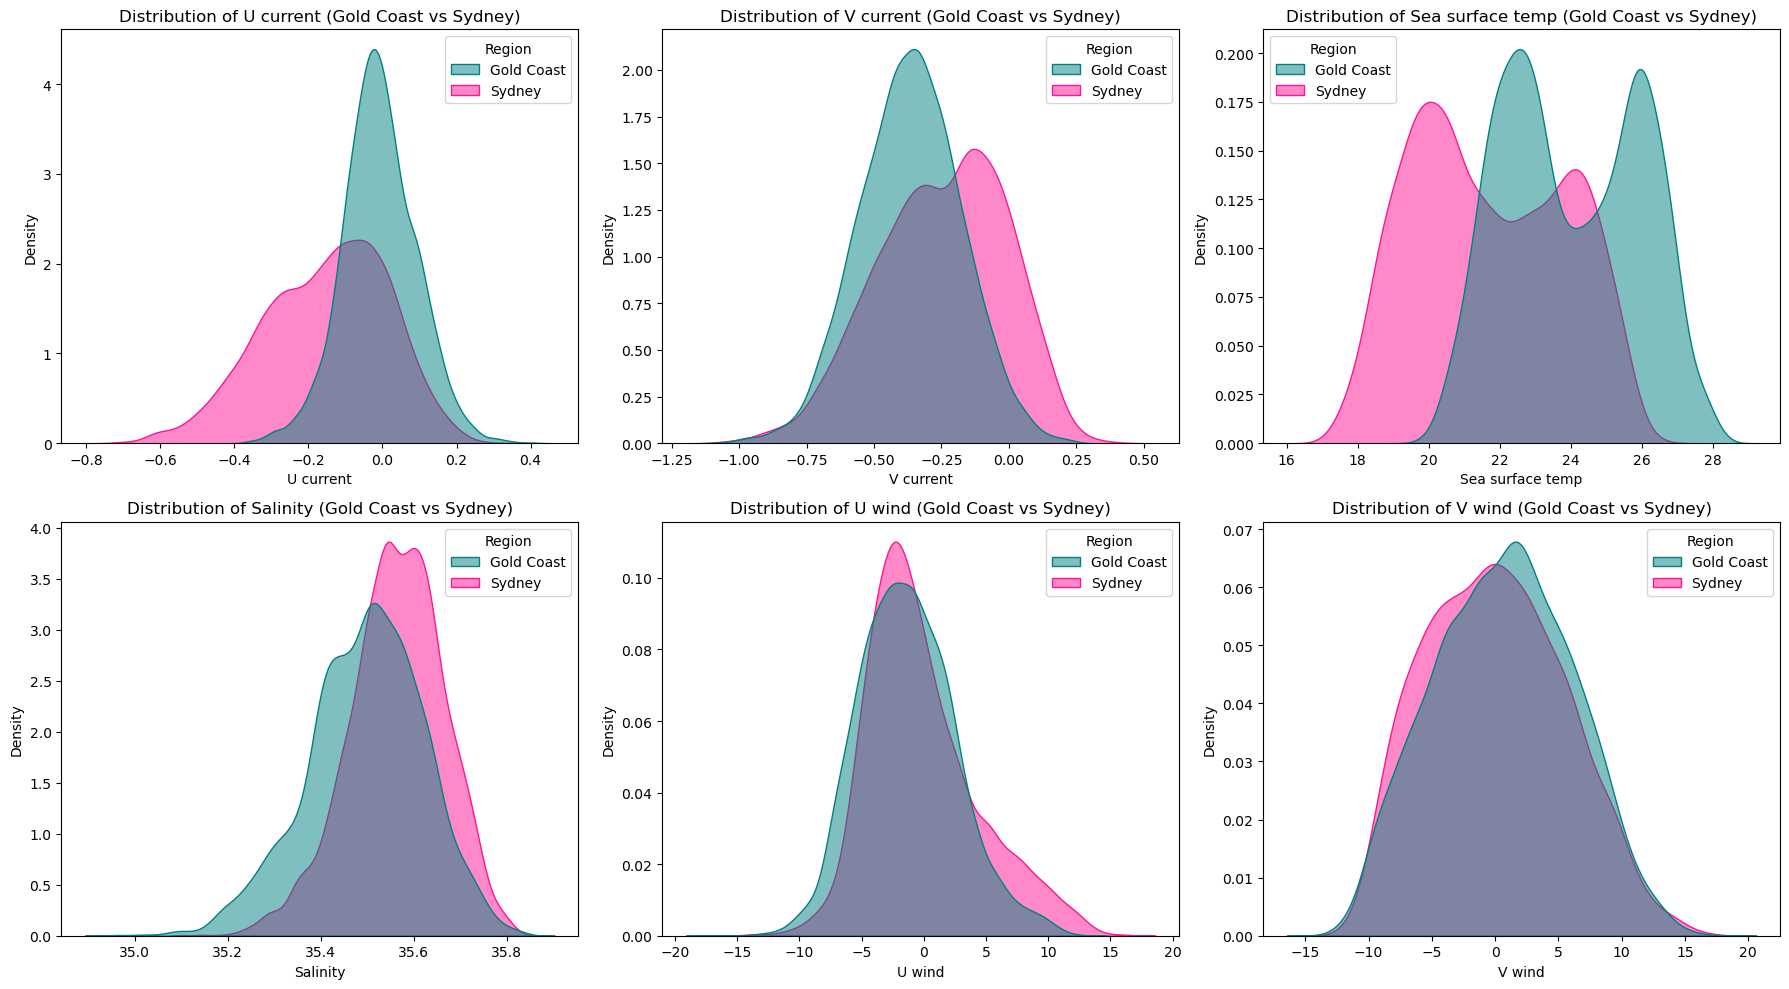

In [6]:
#environmental variables distributions 

palette = {"Gold Coast": "#008080", "Sydney": "#FF1493"}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))  #2x3 grid
axes = axes.flatten()  

for i, evar in enumerate(channel_names):
    sns.kdeplot(
        data=all_df, x=evar, hue="Region",
        fill=True, common_norm=False, alpha=0.5,
        palette=palette, ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {evar} (Gold Coast vs Sydney)")
    axes[i].set_xlabel(evar)
    axes[i].set_ylabel("Density")

plt.tight_layout()
plt.show()

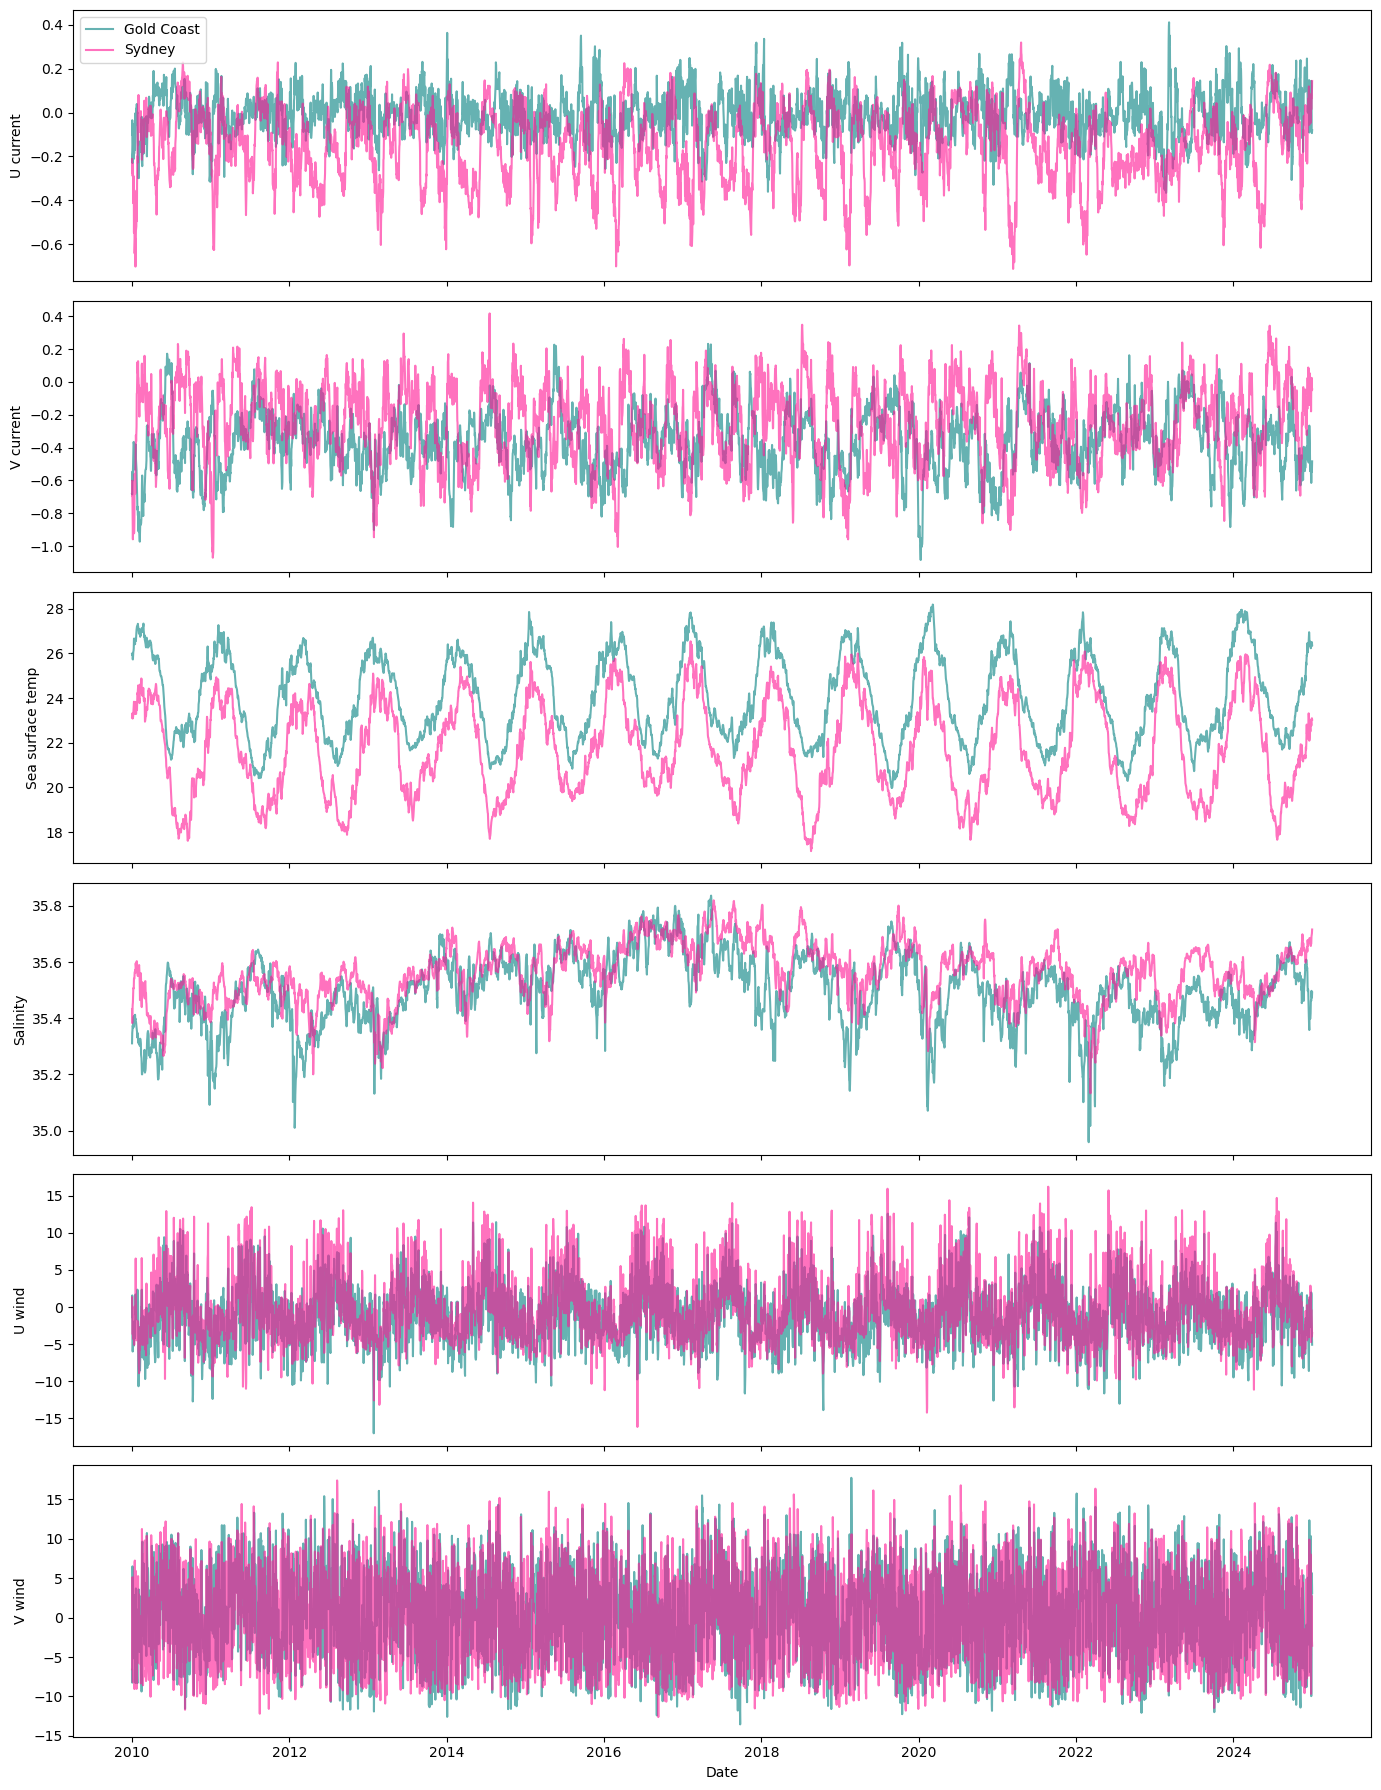

In [8]:
#time series analysis 

fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)

for i, evar in enumerate(channel_names):
    ax = axes[i]
    ax.plot(gc_df.index, gc_df[evar], 
            label="Gold Coast", color=palette["Gold Coast"], alpha=0.6)
    ax.plot(sy_df.index, sy_df[evar], 
            label="Sydney", color=palette["Sydney"], alpha=0.6)
    
    ax.set_ylabel(evar)
    if i == 0:
        ax.legend()
    if i == 5:
        ax.set_xlabel("Date")

plt.tight_layout()
plt.show()


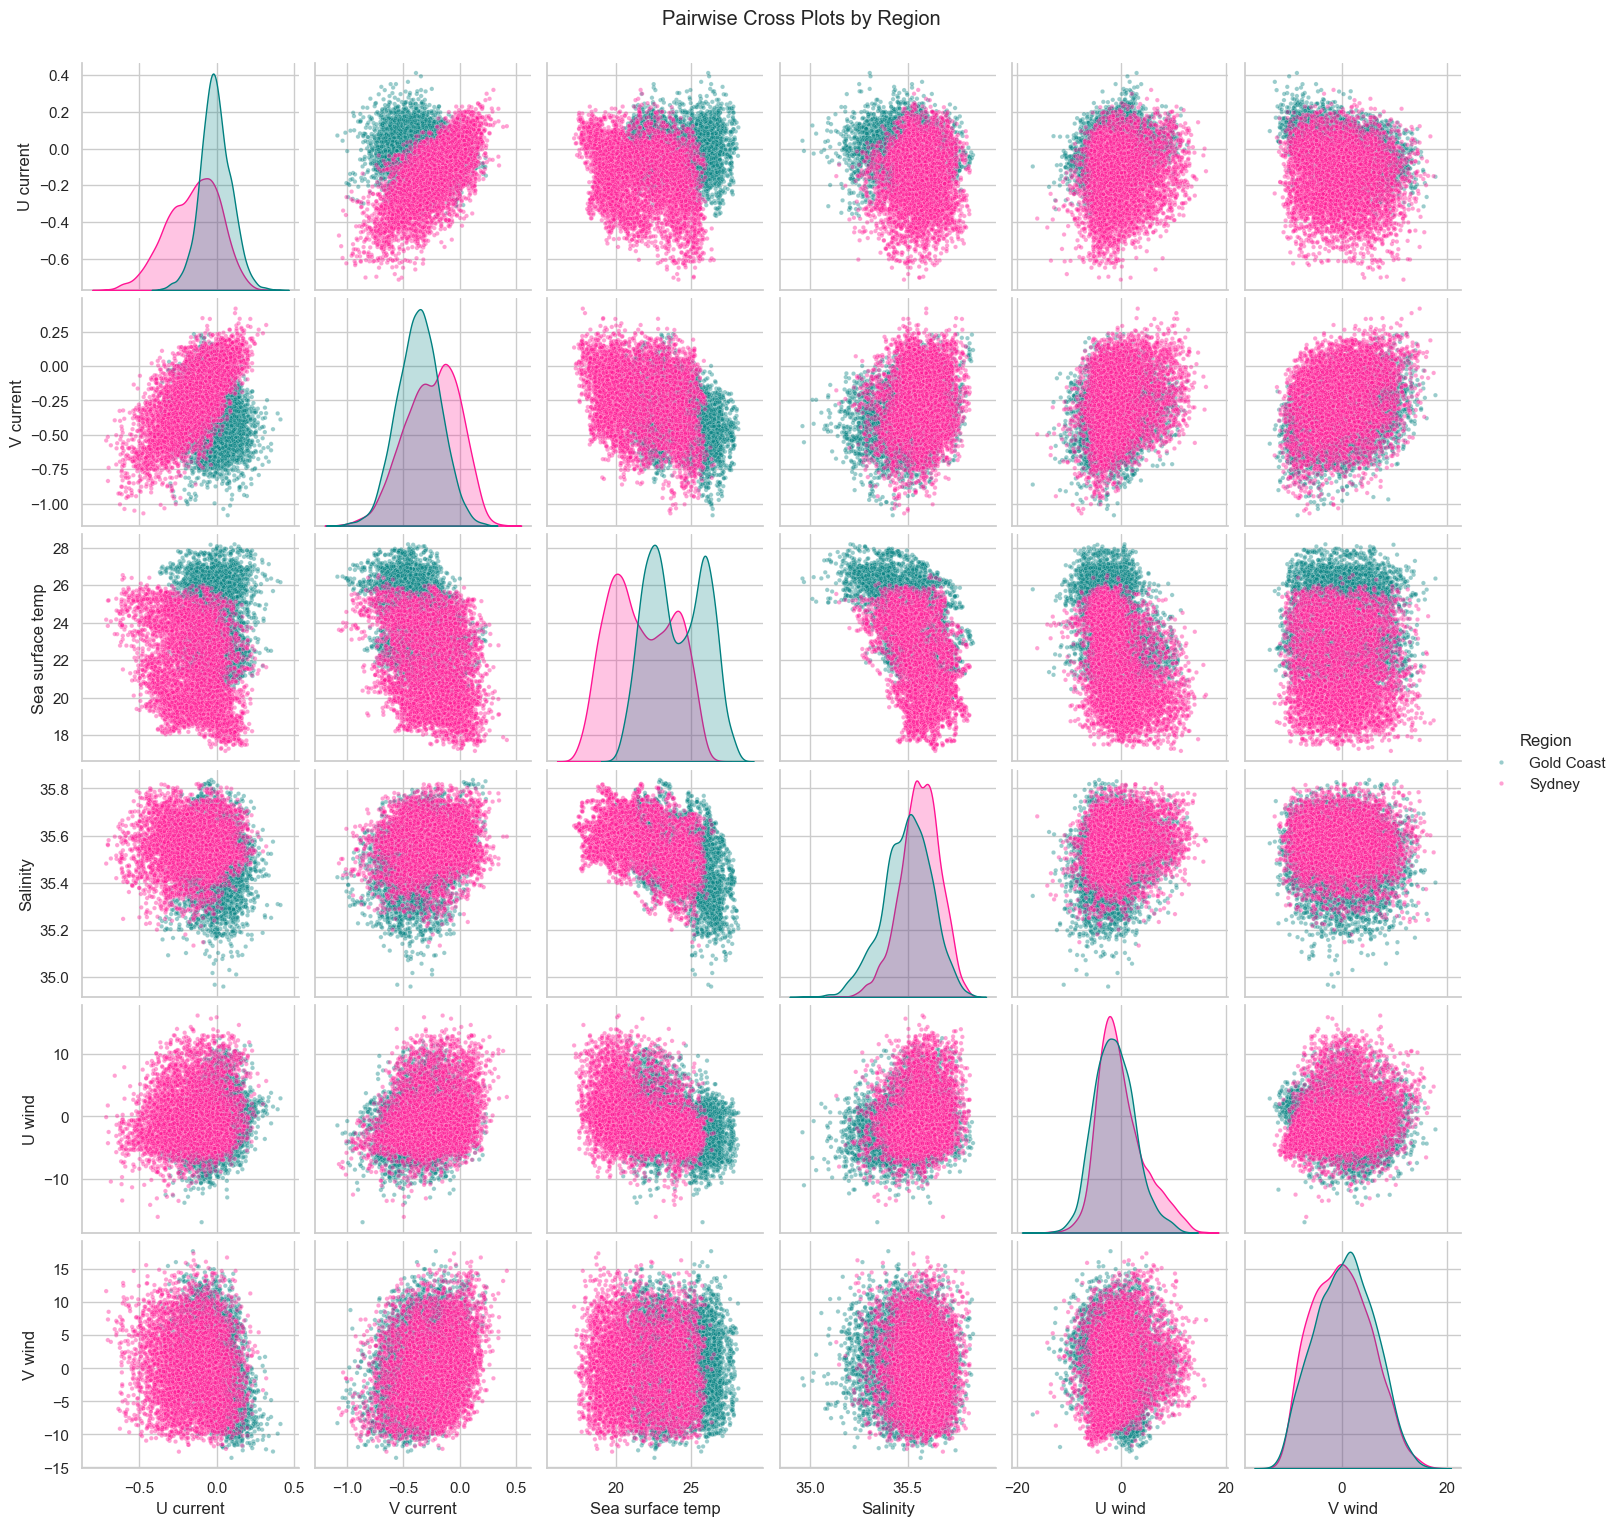

In [10]:
#cross plots by region
sns.set(style="whitegrid")
cp = sns.pairplot(
    all_df,
    vars=["U current", "V current", "Sea surface temp", "Salinity", "U wind", "V wind"],
    hue="Region",
    diag_kind="kde",
    palette=palette,
    plot_kws={"alpha":0.4, "s":10})
cp.fig.suptitle("Pairwise Cross Plots by Region", y=1.02)
plt.show()

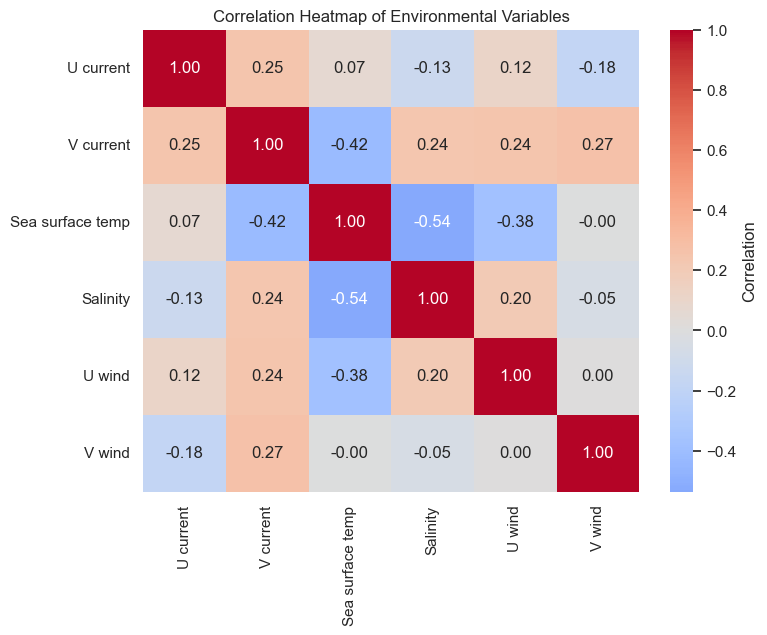

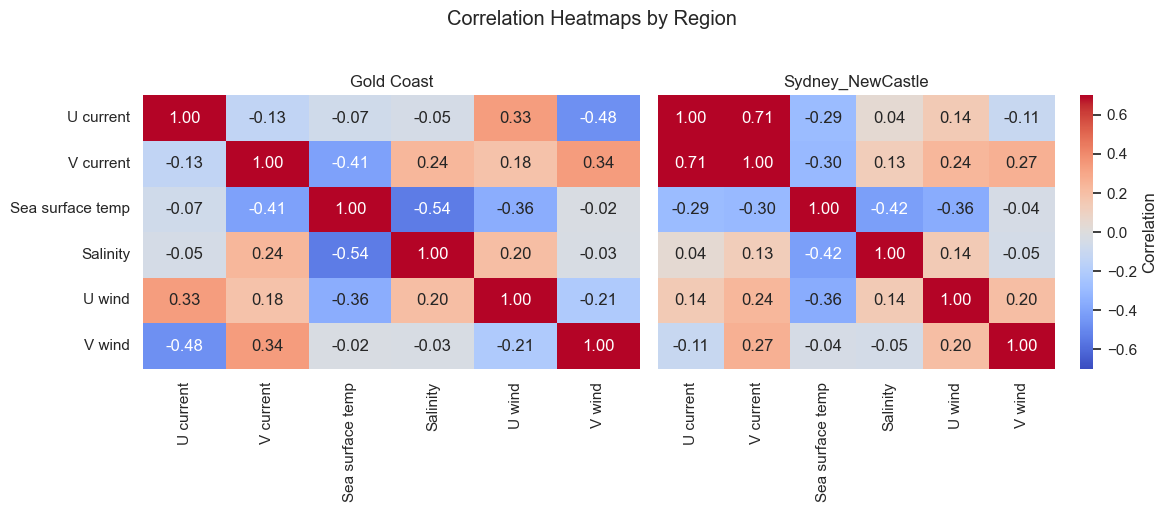

In [11]:
#correlation heatmap

corr = all_df.drop(columns=["Region"]).corr()
cmap = "coolwarm"   
plt.figure(figsize=(8,6))
sns.heatmap(
    corr, annot=True, fmt=".2f",
    cmap=cmap, center=0,
    cbar_kws={'label': 'Correlation'}
)
plt.title("Correlation Heatmap of Environmental Variables")
plt.show()

#correlation heatmaps by region

e_vars = ["U current","V current","Sea surface temp","Salinity","U wind","V wind"]
corr_gc = gc_df[e_vars].corr()
corr_sy = sy_df[e_vars].corr()
cmap = "coolwarm" 

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)

sns.heatmap(corr_gc, ax=axes[0], cmap=cmap, center=0, vmin=-0.7, vmax=0.7,
            annot=True, fmt=".2f", cbar=False)
axes[0].set_title("Gold Coast")

sns.heatmap(corr_sy, ax=axes[1], cmap=cmap, center=0, vmin=-0.7, vmax=0.7,
            annot=True, fmt=".2f", cbar_kws={'label':'Correlation'})
axes[1].set_title("Sydney_NewCastle")

plt.suptitle("Correlation Heatmaps by Region", y=1.02)
plt.tight_layout()
plt.show()



Summary for Sydney
count    1821.000000
mean       53.672158
std       221.514938
min         0.000000
25%         0.000000
50%         0.000000
75%        23.000000
max      4450.000000
Name: stings_sum, dtype: float64
Binary counts:
 stings_binary
0    0.731466
1    0.268534
Name: proportion, dtype: float64

Summary for Gold Coast
count     797.000000
mean       32.899624
std       108.964184
min         0.000000
25%         0.000000
50%         0.000000
75%        24.000000
max      1704.000000
Name: stings_sum, dtype: float64
Binary counts:
 stings_binary
0    0.715182
1    0.284818
Name: proportion, dtype: float64


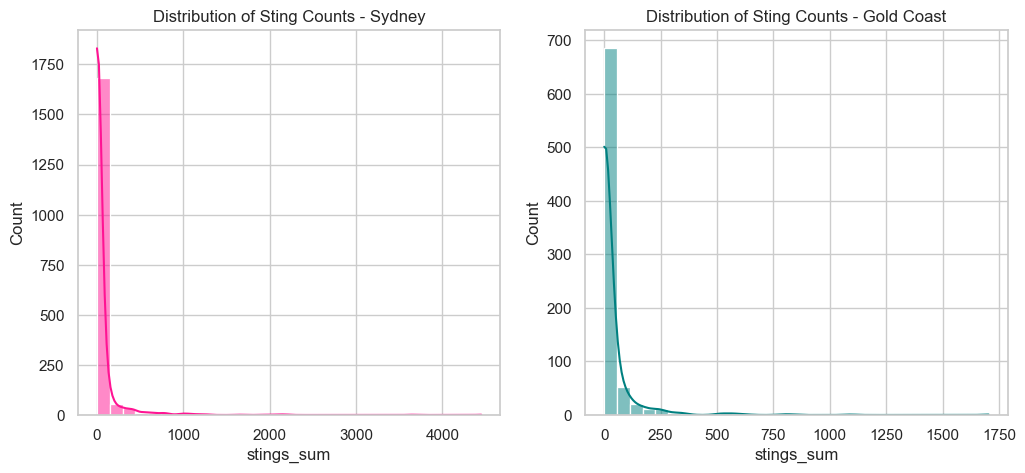

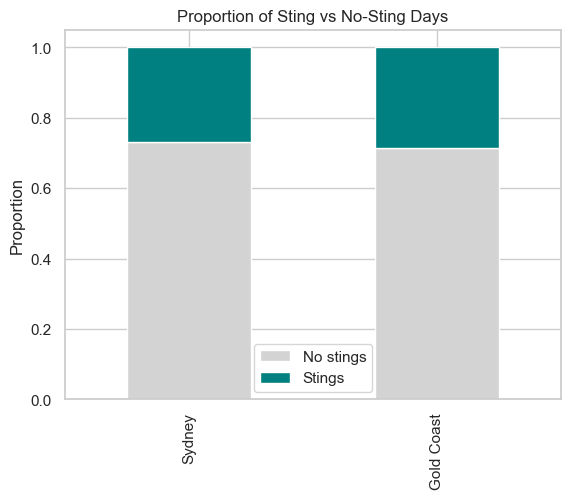

In [12]:
#exploring sting data 

def sting_summary(df, region):
    print(f"\nSummary for {region}")
    print(df["stings_sum"].describe())
    print("Binary counts:\n", df["stings_binary"].value_counts(normalize=True))

sting_summary(sy, "Sydney")
sting_summary(gc, "Gold Coast")

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(sy["stings_sum"], bins=30, kde=True, color=palette["Sydney"], ax=axes[0])
axes[0].set_title("Distribution of Sting Counts - Sydney")

sns.histplot(gc["stings_sum"], bins=30, kde=True, color=palette["Gold Coast"], ax=axes[1])
axes[1].set_title("Distribution of Sting Counts - Gold Coast")

plt.show()


binary_df = pd.DataFrame({
    "Sydney": sy["stings_binary"].value_counts(normalize=True),
    "Gold Coast": gc["stings_binary"].value_counts(normalize=True)
}).T

binary_df.plot(kind="bar", stacked=True, color=["lightgray","teal"])
plt.title("Proportion of Sting vs No-Sting Days")
plt.ylabel("Proportion")
plt.legend(["No stings","Stings"])
plt.show()

In [13]:
#matching sting data with environment data

def daily_env_from_np(arr, region, channels):
    means = np.nanmean(arr, axis=(2, 3))  
    out = pd.DataFrame(means, columns=channels)
    out['date'] = dates
    out['Region'] = region
    return out

gc_env = daily_env_from_np(gc_main, 'Gold Coast', channel_names)
sy_env = daily_env_from_np(sy_main, 'Sydney', channel_names)

env_daily = pd.concat([gc_env, sy_env], ignore_index=True)
merged = env_daily.merge(stings, on=['Region','date'], how='inner')

print('Sydney rows:', (merged.Region=='Sydney').sum(),
      'Gold Coast rows:', (merged.Region=='Gold Coast').sum(),
      'Total:', len(merged))


Sydney rows: 1658 Gold Coast rows: 744 Total: 2402


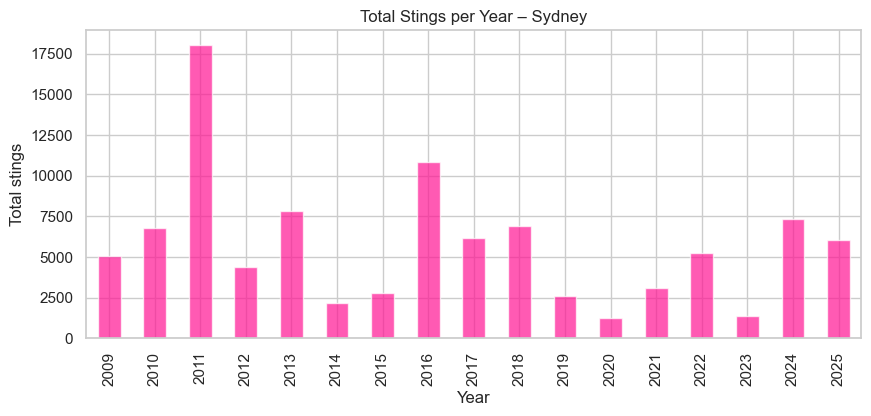

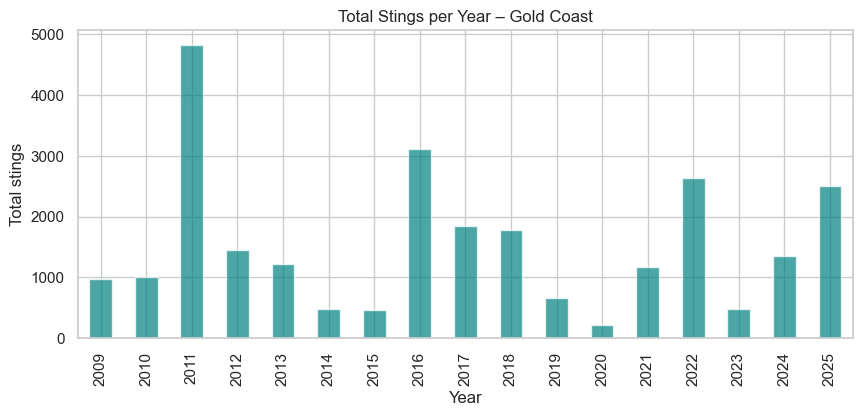

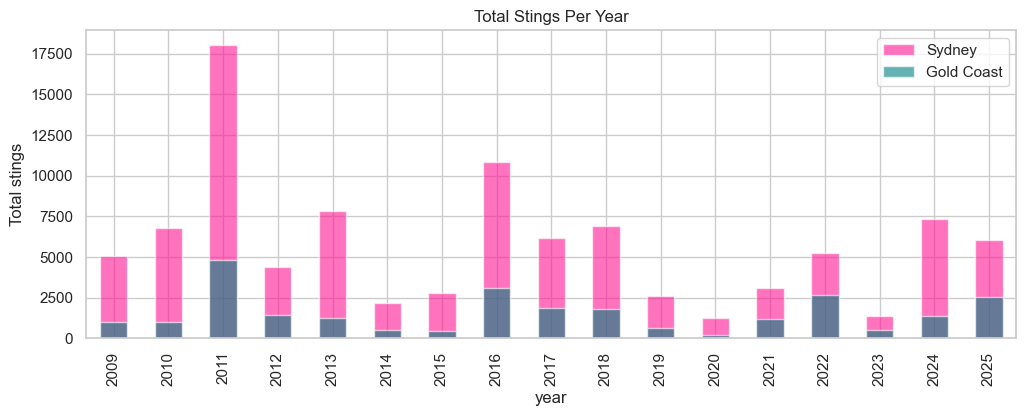

In [14]:
#yearly trends for stings

sy['year'] = sy['date'].dt.year
gc['year'] = gc['date'].dt.year

# Sydney yearly trend
plt.figure(figsize=(10,4))
sy.groupby('year')['stings_sum'].sum().plot(
    kind='bar', color='deeppink', alpha=0.7
)
plt.title('Total Stings per Year – Sydney')
plt.ylabel('Total stings')
plt.xlabel('Year')
plt.show()

# Gold Coast yearly trend
plt.figure(figsize=(10,4))
gc.groupby('year')['stings_sum'].sum().plot(
    kind='bar', color='teal', alpha=0.7
)
plt.title('Total Stings per Year – Gold Coast')
plt.ylabel('Total stings')
plt.xlabel('Year')
plt.show()

#combined
plt.figure(figsize=(12,4))
sy.groupby('year')['stings_sum'].sum().plot(kind='bar', alpha=0.6, color='deeppink', label='Sydney')
gc.groupby('year')['stings_sum'].sum().plot(kind='bar', alpha=0.6, color='teal', label='Gold Coast')
plt.title('Total Stings Per Year')
plt.ylabel('Total stings')
plt.legend()
plt.show()



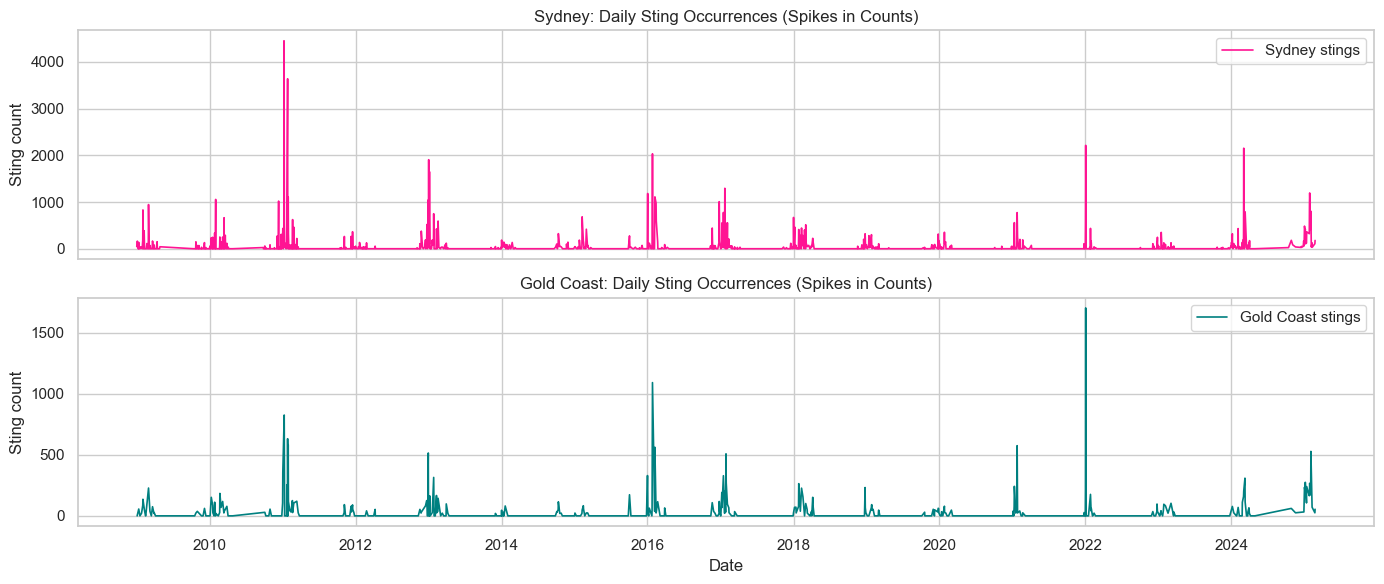

In [15]:
#time series plot of daily sting occurrences

sy_plot = sy.set_index('date').sort_index()
gc_plot = gc.set_index('date').sort_index()
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Sydney plot
axes[0].plot(sy_plot.index, sy_plot['stings_sum'].fillna(0),
             color='deeppink', linewidth=1.2, label='Sydney stings')
axes[0].set_title("Sydney: Daily Sting Occurrences (Spikes in Counts)")
axes[0].set_ylabel("Sting count")
axes[0].legend()

# Gold Coast
axes[1].plot(gc_plot.index, gc_plot['stings_sum'].fillna(0),
             color='teal', linewidth=1.2, label='Gold Coast stings')
axes[1].set_title("Gold Coast: Daily Sting Occurrences (Spikes in Counts)")
axes[1].set_ylabel("Sting count")
axes[1].legend()

plt.xlabel("Date")
plt.tight_layout()
plt.show()


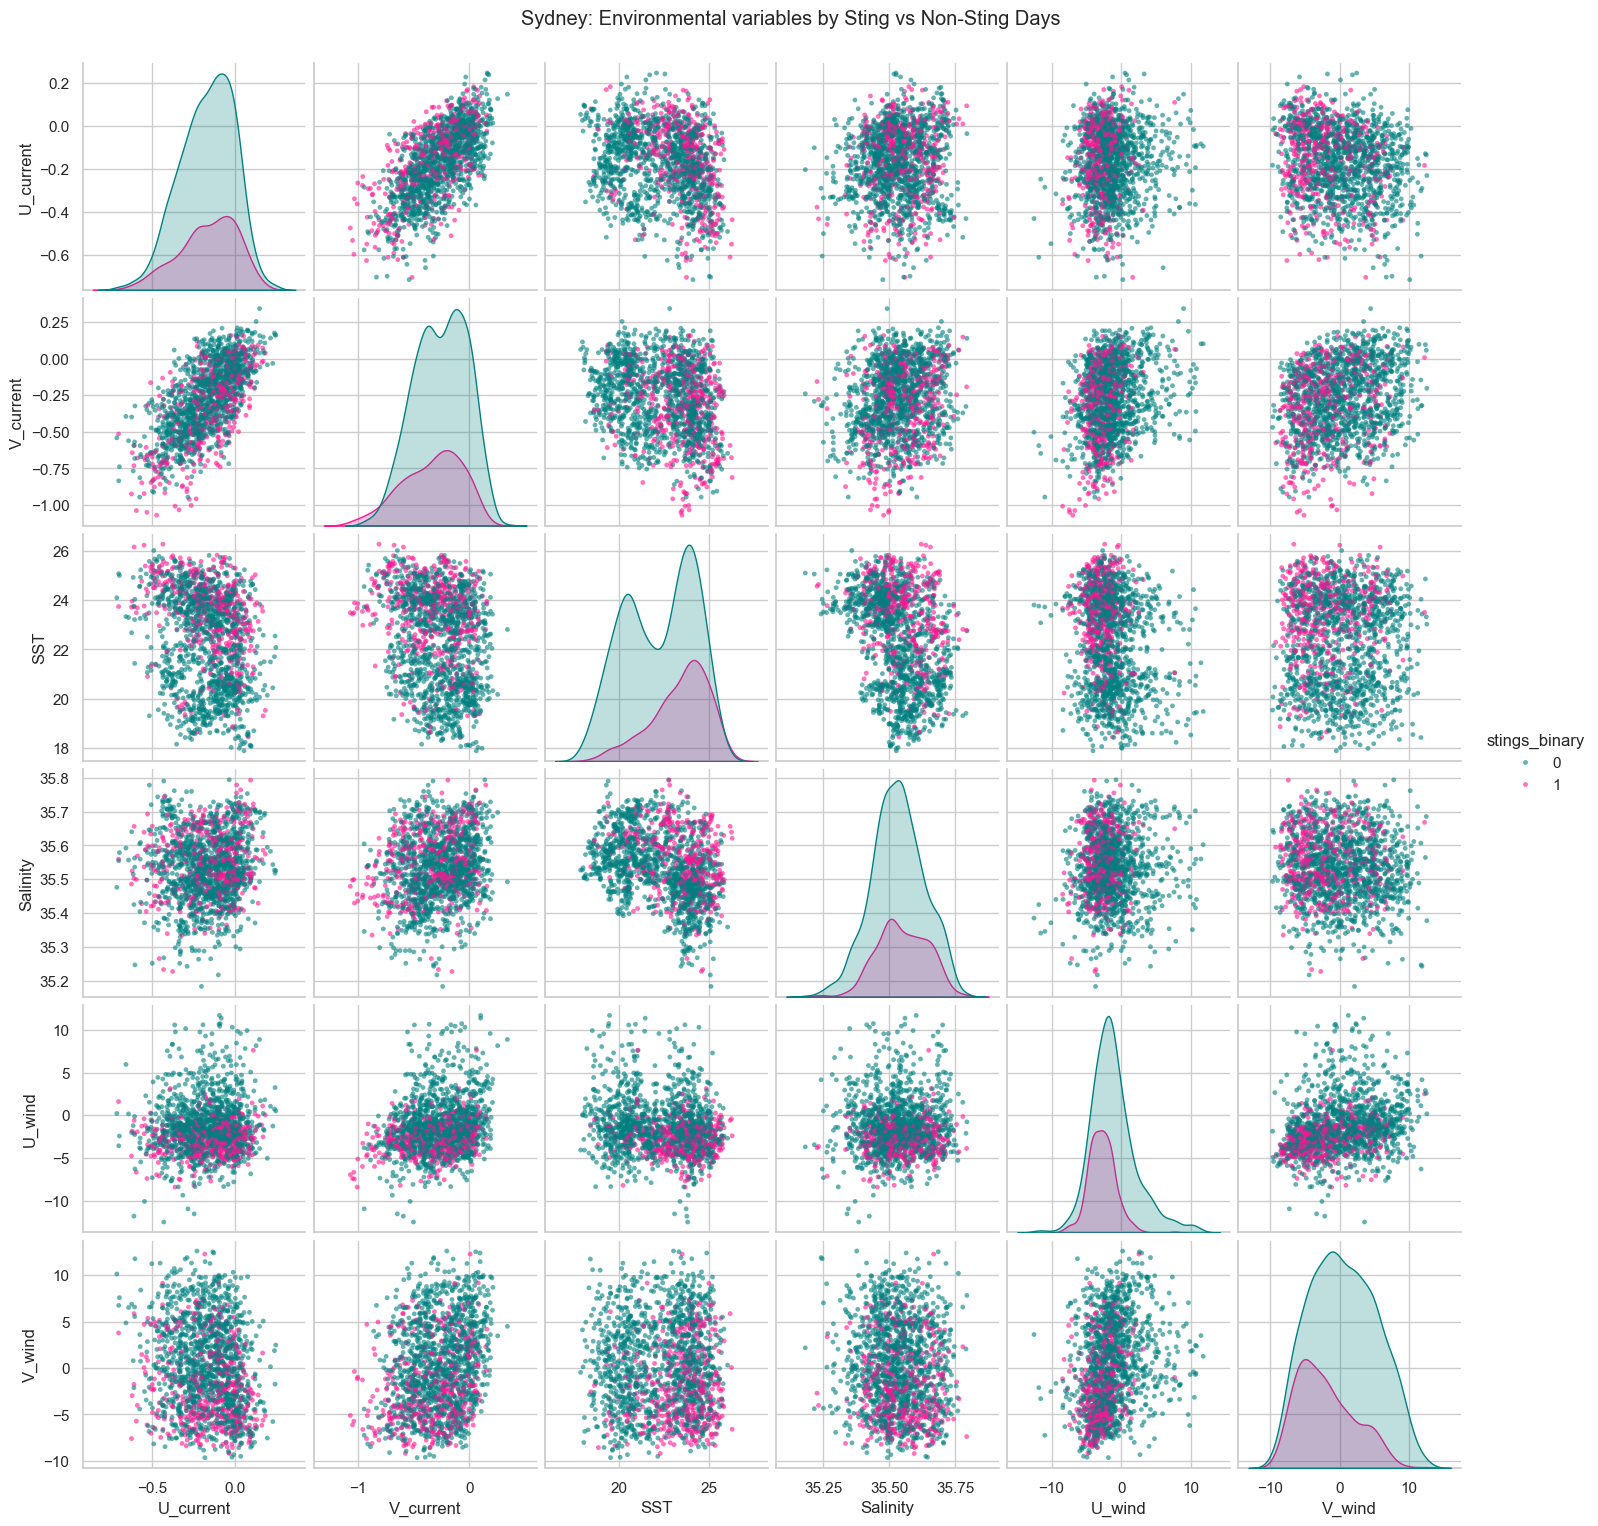

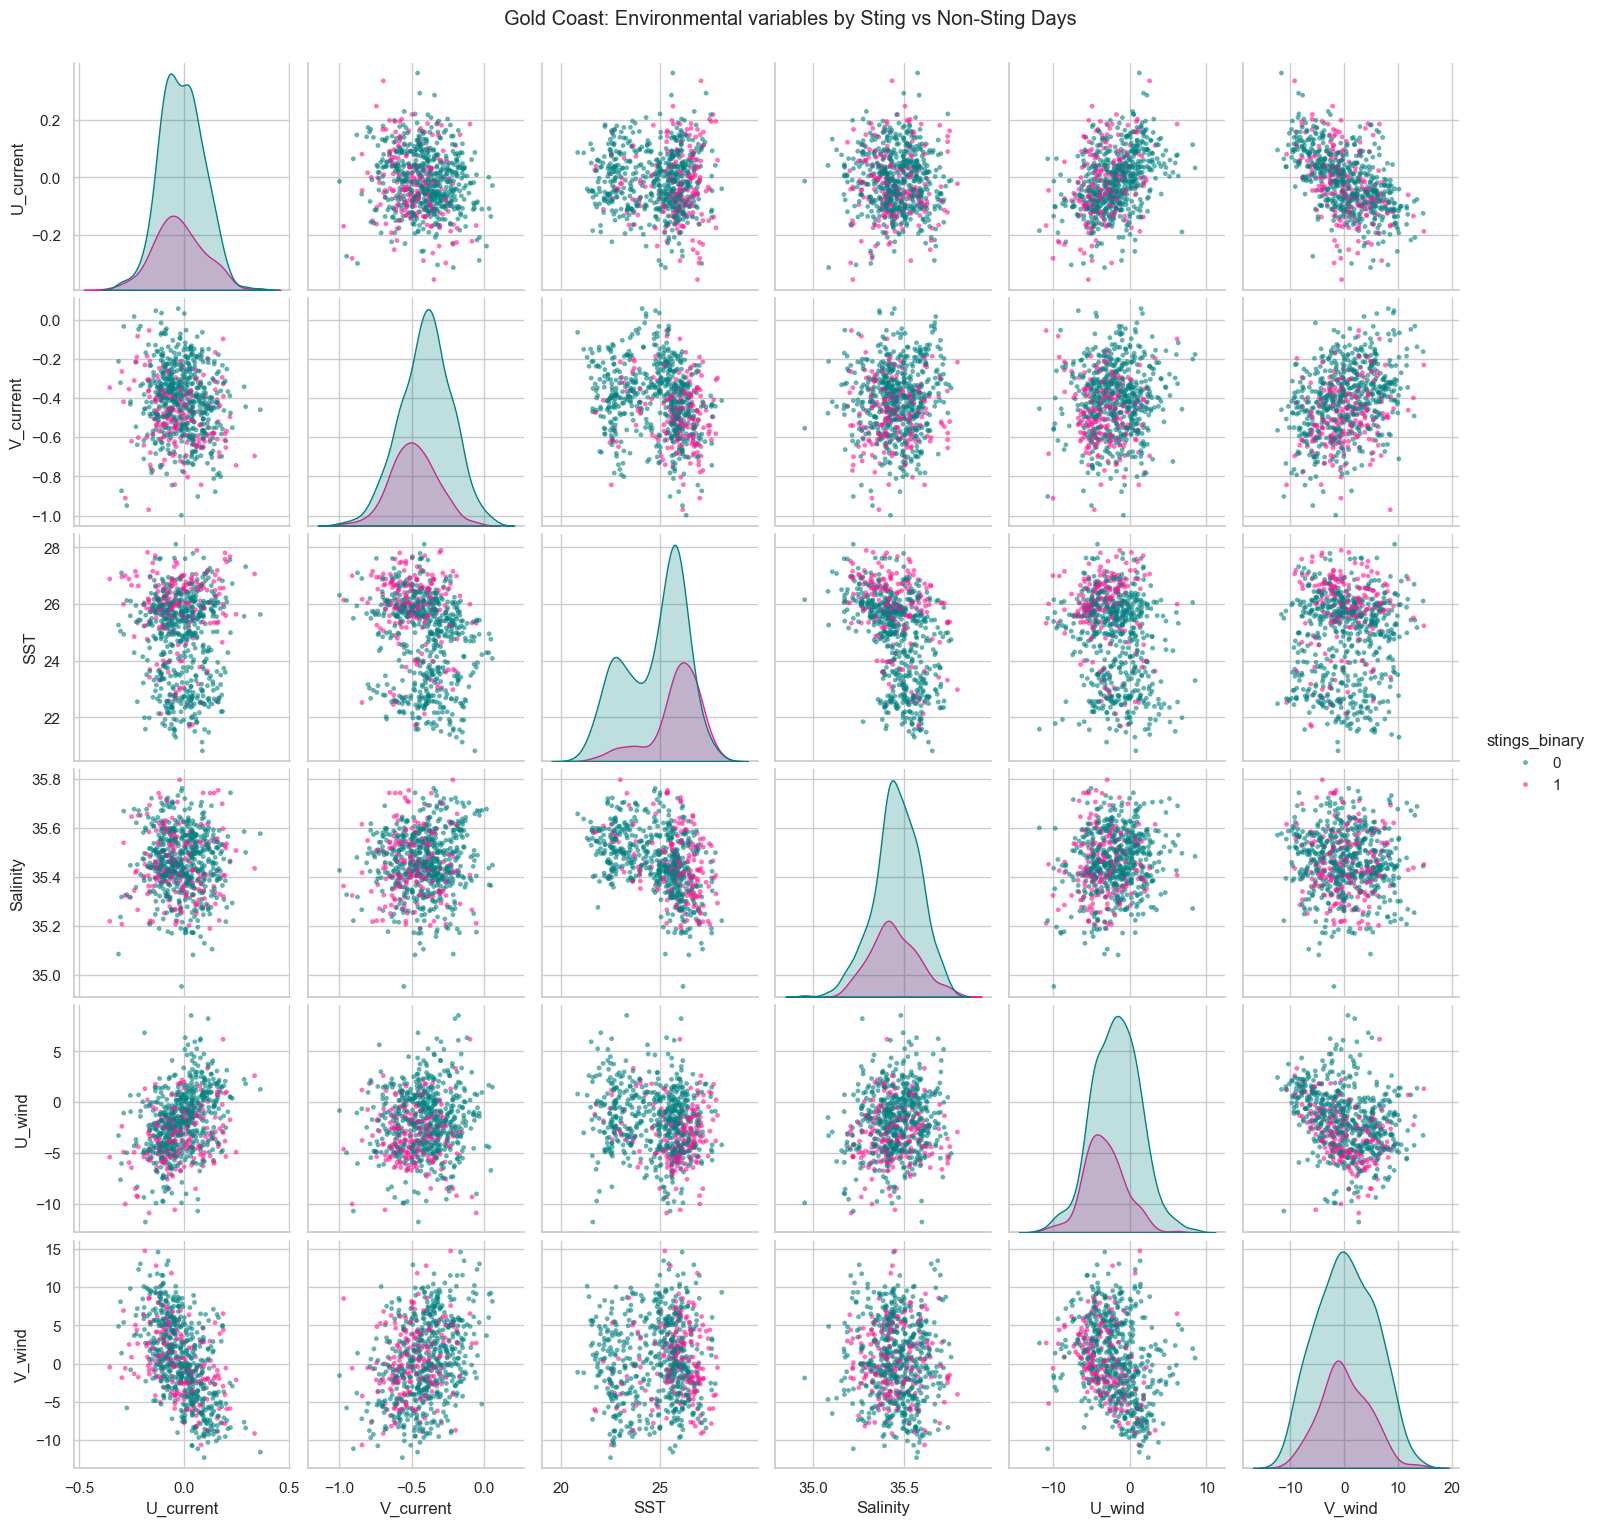

In [16]:
#cross plots of environmental varibles with sting days

rename_map = {
    "U current":"U_current",
    "V current":"V_current",
    "Sea surface temp":"SST",
    "Salinity":"Salinity",
    "U wind":"U_wind",
    "V wind":"V_wind"
}
df = merged.rename(columns=rename_map, errors="ignore")

#Sydney
sy_pairs = df[df["Region"]=="Sydney"].copy()
h = sns.pairplot(
    sy_pairs,
    vars=["U_current","V_current","SST","Salinity","U_wind","V_wind"],
    hue="stings_binary",
    diag_kind="kde",
    palette={0:"teal", 1:"deeppink"},  
    plot_kws=dict(s=12, alpha=0.6, linewidth=0)
)
h.fig.suptitle("Sydney: Environmental variables by Sting vs Non-Sting Days", y=1.02)
plt.show()

#Gold coast
gc_pairs = df[df["Region"]=="Gold Coast"].copy()
m = sns.pairplot(
    gc_pairs,
    vars=["U_current","V_current","SST","Salinity","U_wind","V_wind"],
    hue="stings_binary",
    diag_kind="kde",
    palette={0:"teal", 1:"deeppink"},   
    plot_kws=dict(s=12, alpha=0.6, linewidth=0)
)
m.fig.suptitle("Gold Coast: Environmental variables by Sting vs Non-Sting Days", y=1.02)
plt.show()

In [54]:
# Setup
import math, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# Device
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Config
CONFIG = {
    "win_t": 3,                 # days per input window
    "BATCH_SIZE": 32,
    "LR": 5e-4,
    "EPOCHS": 15,
    "MAX_GRAD_NORM": 2.0,
    "TRAIN_END_YEAR": 2018,     # train: <= 2018
    "VAL_END_YEAR": 2021,       # val:   2019-2021, test: >= 2022
    "DROPOUT": 0.2,
    "WEIGHT_DECAY": 1e-4,
}
LABEL_COL = "stings_binary"

# label merge
dates = pd.to_datetime(pd.Series(dates), utc=False).dt.normalize()

gc_idx = pd.DataFrame({"date": dates, "Region": "Gold Coast", "tidx": np.arange(len(dates))})
sy_idx = pd.DataFrame({"date": dates, "Region": "Sydney",     "tidx": np.arange(len(dates))})

st = stings.copy()
if LABEL_COL not in st.columns:
    for cand in ["stings_binary", "Sting", "StingFlag", "label", "y"]:
        if cand in st.columns: LABEL_COL = cand; break

st["date"] = pd.to_datetime(st["date"], utc=False).dt.normalize()
st["Region"] = st["Region"].astype(str)

gc_map = gc_idx.merge(st[["Region","date", LABEL_COL]], on=["Region","date"], how="inner")
sy_map = sy_idx.merge(st[["Region","date", LABEL_COL]], on=["Region","date"], how="inner")

print("Matched GC days:", len(gc_map), "| Sydney days:", len(sy_map))
print("Positives GC:", int(gc_map[LABEL_COL].sum()), "| Sydney:", int(sy_map[LABEL_COL].sum()))


Matched GC days: 744 | Sydney days: 1658
Positives GC: 199 | Sydney: 436


In [55]:
# Sequences (windows)
def build_sequences_lastN_valid(index_df: pd.DataFrame,
                                arr: np.ndarray,
                                label_col: str,
                                region_name: str,
                                win_t: int = 3,
                                positive_only: bool = False):
    assert win_t >= 1
    T = arr.shape[0]
    df = index_df.copy()
    df = df[df[label_col].isin([0, 1])]
    if positive_only:
        df = df[df[label_col] == 1]
    seqs = []
    for _, row in df.iterrows():
        t = int(row["tidx"])  # label day
        y = int(row[label_col])
        start_t = t - (win_t - 1)
        end_t = t
        if start_t < 0 or end_t >= T:
            continue
        seqs.append((start_t, end_t, y, region_name))
    return seqs

# Dataset using mask-based handling only (no imputation bias)
class BluebottleDataset(Dataset):
    def __init__(self, arr_by_region, seqs, mean=None, std=None, compute_norm=False):
        self.arr_by_region = arr_by_region
        self.seqs = seqs
        if compute_norm:
            chans = []
            for s, e, _, r in self.seqs:
                x = self.arr_by_region[r][s:e+1]
                x = x.reshape(x.shape[0], x.shape[1], -1)
                chans.append(np.nanmean(x, axis=(0, 2)))
            chans = np.stack(chans, axis=0)
            mean = np.nanmean(chans, axis=0)
            std = np.nanstd(chans, axis=0)
            std[~np.isfinite(std)] = 0.0
            std = std + 1e-6
        self.mean = mean
        self.std = std
        assert self.mean is not None and self.std is not None, "mean/std must be set"

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, i):
        s, e, y, r = self.seqs[i]
        x = self.arr_by_region[r][s:e+1]  # (T, C, H, W)
        valid = np.isfinite(x).astype(np.float32)
        x = np.nan_to_num(x, nan=0.0)
        x = (x - self.mean[None, :, None, None]) / self.std[None, :, None, None]
        x = np.clip(x, -10, 10)
        x = x * valid
        x = np.concatenate([x, valid], axis=1)  # (T, 2*C, H, W)
        x = torch.from_numpy(x.astype(np.float32)).permute(1, 0, 2, 3)  # (C,T,H,W)
        y = torch.tensor(float(y), dtype=torch.float32)
        return x, y

# Center pad (H,W) within a batch
def pad_collate(batch):
    Hmax = max(x.shape[2] for x, _ in batch)
    Wmax = max(x.shape[3] for x, _ in batch)
    xs, ys = [], []
    for x, y in batch:
        _, _, H, W = x.shape
        pad_h_top = (Hmax - H) // 2
        pad_h_bottom = Hmax - H - pad_h_top
        pad_w_left = (Wmax - W) // 2
        pad_w_right = Wmax - W - pad_w_left
        x = F.pad(x, (pad_w_left, pad_w_right, pad_h_top, pad_h_bottom))
        xs.append(x)
        ys.append(y)
    return torch.stack(xs, 0), torch.stack(ys, 0)


In [56]:
# Chronological split

def split_train_val_test(index_df, train_end=CONFIG["TRAIN_END_YEAR"], val_end=CONFIG["VAL_END_YEAR"]):
    df = index_df.copy()
    df['year'] = pd.to_datetime(df['date']).dt.year
    train_df = df[df['year'] <= train_end].copy()
    val_df = df[(df['year'] > train_end) & (df['year'] <= val_end)].copy()
    test_df = df[df['year'] > val_end].copy()
    return train_df, val_df, test_df

# Build splits

gc_train_idx, gc_val_idx, gc_test_idx = split_train_val_test(gc_map)
sy_train_idx, sy_val_idx, sy_test_idx = split_train_val_test(sy_map)

# Sequences

gc_train_seqs = build_sequences_lastN_valid(gc_train_idx, gc_main, LABEL_COL, "Gold Coast", win_t=CONFIG["win_t"])
gc_val_seqs = build_sequences_lastN_valid(gc_val_idx, gc_main, LABEL_COL, "Gold Coast", win_t=CONFIG["win_t"])
gc_test_seqs = build_sequences_lastN_valid(gc_test_idx, gc_main, LABEL_COL, "Gold Coast", win_t=CONFIG["win_t"])

sy_train_seqs = build_sequences_lastN_valid(sy_train_idx, sy_main, LABEL_COL, "Sydney", win_t=CONFIG["win_t"])
sy_val_seqs = build_sequences_lastN_valid(sy_val_idx, sy_main, LABEL_COL, "Sydney", win_t=CONFIG["win_t"])
sy_test_seqs = build_sequences_lastN_valid(sy_test_idx, sy_main, LABEL_COL, "Sydney", win_t=CONFIG["win_t"])

print(f"GC seqs -> train:{len(gc_train_seqs)} val:{len(gc_val_seqs)} test:{len(gc_test_seqs)}")
print(f"SY seqs -> train:{len(sy_train_seqs)} val:{len(sy_val_seqs)} test:{len(sy_test_seqs)}")

# Arrays per region
arrays_gc = {"Gold Coast": gc_main}
arrays_sy = {"Sydney": sy_main}

# Datasets (per-region normalization from train only)
train_ds_gc = BluebottleDataset(arrays_gc, gc_train_seqs, compute_norm=True)
val_ds_gc = BluebottleDataset(arrays_gc, gc_val_seqs, mean=train_ds_gc.mean, std=train_ds_gc.std)
test_ds_gc = BluebottleDataset(arrays_gc, gc_test_seqs, mean=train_ds_gc.mean, std=train_ds_gc.std)

train_ds_sy = BluebottleDataset(arrays_sy, sy_train_seqs, compute_norm=True)
val_ds_sy = BluebottleDataset(arrays_sy, sy_val_seqs, mean=train_ds_sy.mean, std=train_ds_sy.std)
test_ds_sy = BluebottleDataset(arrays_sy, sy_test_seqs, mean=train_ds_sy.mean, std=train_ds_sy.std)

GC seqs -> train:455 val:162 test:127
SY seqs -> train:1037 val:269 test:351


In [57]:
# Summaries

def summarize_year_split3(df_train, df_val, df_test, region):
    def yr_rng(df):
        return (df['year'].min(), df['year'].max()) if len(df) else (None, None)
    tr = yr_rng(df_train); va = yr_rng(df_val); te = yr_rng(df_test)
    print(f"\n{region} — Train {tr[0]}-{tr[1]} | Val {va[0]}-{va[1]} | Test {te[0]}-{te[1]}")
    print(f"Train days: {len(df_train)} (pos {df_train[LABEL_COL].sum()}), "
          f"Val days: {len(df_val)} (pos {df_val[LABEL_COL].sum()}), "
          f"Test days: {len(df_test)} (pos {df_test[LABEL_COL].sum()})")

summarize_year_split3(gc_train_idx, gc_val_idx, gc_test_idx, "Gold Coast")
summarize_year_split3(sy_train_idx, sy_val_idx, sy_test_idx, "Sydney")

# Imbalance weights
ys_gc = np.array([y for _, _, y, _ in gc_train_seqs], dtype=np.int64)
pos_weight_gc = (len(ys_gc) - ys_gc.sum()) / (ys_gc.sum() + 1e-6)
ys_sy = np.array([y for _, _, y, _ in sy_train_seqs], dtype=np.int64)
pos_weight_sy = (len(ys_sy) - ys_sy.sum()) / (ys_sy.sum() + 1e-6)
print(f"pos_weight GC≈ {float(pos_weight_gc):.2f} | SY≈ {float(pos_weight_sy):.2f}")

# Loaders (Windows/Jupyter-safe)
loader_kwargs = dict(batch_size=CONFIG["BATCH_SIZE"], drop_last=False, collate_fn=pad_collate,
                     num_workers=0, pin_memory=(DEVICE=="cuda"))
train_loader_gc = DataLoader(train_ds_gc, shuffle=True, **loader_kwargs)
val_loader_gc   = DataLoader(val_ds_gc,   shuffle=False, **loader_kwargs)
test_loader_gc  = DataLoader(test_ds_gc,  shuffle=False, **loader_kwargs)

train_loader_sy = DataLoader(train_ds_sy, shuffle=True, **loader_kwargs)
val_loader_sy   = DataLoader(val_ds_sy,   shuffle=False, **loader_kwargs)
test_loader_sy  = DataLoader(test_ds_sy,  shuffle=False, **loader_kwargs)


Gold Coast — Train 2010-2018 | Val 2019-2021 | Test 2022-2024
Train days: 455 (pos 134), Val days: 162 (pos 29), Test days: 127 (pos 36)

Sydney — Train 2010-2018 | Val 2019-2021 | Test 2022-2024
Train days: 1038 (pos 297), Val days: 269 (pos 58), Test days: 351 (pos 81)
pos_weight GC≈ 2.40 | SY≈ 2.50


In [58]:
# PositionalEncoding, Spatial CNN, Temporal Transformer


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe)
    def forward(self, x):
        T = x.size(1)
        return x + self.pe[:T].unsqueeze(0)
#this gives every day in our input window a time stamp. It creates a fixed pattern of sine and cos waves which represent position in the sequence that a tranformer is able to understand.

class SpatialEncoder2D(nn.Module):
    def __init__(self, in_ch: int, d_model: int = 128, base: int = 32, dropout: float = 0.2):
        super().__init__()
        self.in_ch = in_ch
        self.base = base
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_ch, base, kernel_size=3, padding=1),
            nn.BatchNorm2d(base), nn.ReLU(inplace=True),
            nn.Conv2d(base, base, kernel_size=3, padding=1),
            nn.BatchNorm2d(base), nn.ReLU(inplace=True),
        )
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Sequential(
            nn.Conv2d(base, base*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base*2), nn.ReLU(inplace=True),
        )
        self.proj = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(base*2, d_model)
        )

    def forward(self, x2d):
        # x2d: (B*T, Ctot, H, W) with Ctot = 2 * C (data + validity)
        ctot = x2d.shape[1]
        c_data = ctot // 2
        # derive a single spatial mask from validity channels
        v = x2d[:, c_data:, :, :].mean(dim=1, keepdim=True)  # (B*T,1,H,W)
        v_bin = (v > 0.5).float()

        h = self.conv1(x2d)
        v1 = F.max_pool2d(v_bin, kernel_size=2, stride=2)
        h = self.pool(h)
        h = self.conv2(h)

        # masked global average pooling
        eps = 1e-6
        v_area = v1.sum(dim=(2,3)).clamp_min(eps)  # (B*T,1)
        h_sum = (h * v1).sum(dim=(2,3))           # (B*T, C)
        h_avg = h_sum / v_area                     # (B*T, C)
        out = self.proj(h_avg)
        return out

class CNNTemporalTransformer(nn.Module):
    def __init__(self, in_ch: int, d_model: int = 128, nhead: int = 4, num_layers: int = 2,
                 dropout: float = 0.2, use_cls: bool = True):
        super().__init__()
        self.spatial = SpatialEncoder2D(in_ch, d_model, base=32, dropout=dropout)
        self.posenc = PositionalEncoding(d_model)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                               dim_feedforward=4*d_model, dropout=dropout,
                                               batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.use_cls = use_cls
        if use_cls:
            self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
            nn.init.trunc_normal_(self.cls, std=0.02)
        self.head = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(inplace=True), nn.Dropout(CONFIG["DROPOUT"]),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        B, C, T, H, W = x.shape
        x2d = x.permute(0, 2, 1, 3, 4).reshape(B*T, C, H, W)
        feats = self.spatial(x2d)  # (B*T, D)
        D = feats.size(-1)
        tokens = feats.view(B, T, D)
        if self.use_cls:
            cls_tok = self.cls.expand(B, -1, -1)
            tokens = torch.cat([cls_tok, tokens], dim=1)
        tokens = self.posenc(tokens)
        enc = self.encoder(tokens)
        rep = enc[:, 0] if self.use_cls else enc.mean(dim=1)
        logits = self.head(rep).squeeze(1)
        return logits



In [59]:
# Train & eval

def evaluate(model, loader, threshold: float = 0.5):
    model.eval()
    ys, yh, yp = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            prob = torch.sigmoid(logits)
            prob = torch.nan_to_num(prob, nan=0.5)
            ys.append(yb.cpu().numpy())
            yp.append(prob.cpu().numpy())
            yh.append((prob.cpu().numpy() >= threshold).astype(int))
    y_true = np.concatenate(ys); y_prob = np.concatenate(yp); y_hat = np.concatenate(yh)
    metrics = {
        "acc": accuracy_score(y_true, y_hat),
        "prec": precision_score(y_true, y_hat, zero_division=0),
        "rec": recall_score(y_true, y_hat, zero_division=0),
        "f1": f1_score(y_true, y_hat, zero_division=0),
        "auroc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
    }
    return metrics, y_true, y_hat, y_prob


def tune_threshold(y_true, y_prob):
    ts = np.linspace(0.1, 0.9, 81)
    best_f1, best_t = -1.0, 0.5
    for t in ts:
        f1 = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return float(best_t)


def train_model(model, train_loader, val_loader, epochs=CONFIG["EPOCHS"], lr=CONFIG["LR"], pos_weight=None):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=CONFIG["WEIGHT_DECAY"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)

    pos_w = torch.tensor(float(pos_weight), device=DEVICE) if pos_weight is not None else None
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_w) if pos_w is not None else nn.BCEWithLogitsLoss()

    best_state = None
    best_f1 = -1.0

    for ep in range(1, epochs + 1):
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = bce(logits, yb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG["MAX_GRAD_NORM"])
            opt.step()
            batch_losses.append(loss.item())
        val_metrics, *_ = evaluate(model, val_loader)
        scheduler.step(val_metrics["f1"])
        print(f"Epoch {ep:02d} | train_loss={np.mean(batch_losses):.4f} | "
              f"val: acc={val_metrics['acc']:.3f}  prec={val_metrics['prec']:.3f}  "
              f"rec={val_metrics['rec']:.3f}  f1={val_metrics['f1']:.3f}  "
              f"auroc={val_metrics['auroc']:.3f}")
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if best_state is not None:
        model.load_state_dict(best_state)
    return model



In [60]:
# Sydney
in_ch_sy = sy_main.shape[1] * 2
model_sy = CNNTemporalTransformer(in_ch=in_ch_sy, d_model=128, nhead=4, num_layers=2, dropout=CONFIG["DROPOUT"], use_cls=True)
print("\nTraining Sydney model...")
model_sy = train_model(model_sy, train_loader_sy, val_loader_sy, pos_weight=float(pos_weight_sy))
val_report_sy, y_true_sy_val, _, y_prob_sy_val = evaluate(model_sy, val_loader_sy)
th_sy = tune_threshold(y_true_sy_val, y_prob_sy_val)
print(f"Sydney validation (th={th_sy:.2f}):", val_report_sy)

test_report_sy, y_true_sy_test, y_hat_sy_test_default, y_prob_sy_test = evaluate(model_sy, test_loader_sy, threshold=th_sy)
print("Sydney test:", test_report_sy)



Training Sydney model...
Epoch 01 | train_loss=0.9148 | val: acc=0.788  prec=0.508  rec=0.517  f1=0.513  auroc=0.801
Epoch 02 | train_loss=0.8462 | val: acc=0.665  prec=0.375  rec=0.828  f1=0.516  auroc=0.817
Epoch 03 | train_loss=0.8235 | val: acc=0.565  prec=0.314  rec=0.862  f1=0.461  auroc=0.828
Epoch 04 | train_loss=0.8119 | val: acc=0.613  prec=0.345  rec=0.879  f1=0.495  auroc=0.802
Epoch 05 | train_loss=0.8054 | val: acc=0.606  prec=0.338  rec=0.862  f1=0.485  auroc=0.815
Epoch 06 | train_loss=0.7541 | val: acc=0.628  prec=0.350  rec=0.845  f1=0.495  auroc=0.805
Epoch 07 | train_loss=0.7636 | val: acc=0.699  prec=0.398  rec=0.776  f1=0.526  auroc=0.791
Epoch 08 | train_loss=0.7520 | val: acc=0.599  prec=0.326  rec=0.810  f1=0.465  auroc=0.791
Epoch 09 | train_loss=0.7698 | val: acc=0.669  prec=0.374  rec=0.793  f1=0.508  auroc=0.777
Epoch 10 | train_loss=0.7259 | val: acc=0.669  prec=0.360  rec=0.690  f1=0.473  auroc=0.744
Epoch 11 | train_loss=0.7083 | val: acc=0.591  prec=0.

In [61]:
#Sydney model on GC data
# Sydney-trained model evaluated on Gold Coast data
print("\nEvaluating Sydney-trained model on Gold Coast data...")

# Evaluate on Gold Coast validation (optional)
val_report_gc_from_sy, y_true_gc_val, y_hat_gc_val_from_sy, y_prob_gc_val_from_sy = \
    evaluate(model_sy, val_loader_gc, threshold=th_sy)
print("Gold Coast validation (Sydney-trained model):", val_report_gc_from_sy)

# Evaluate on Gold Coast test set
test_report_gc_from_sy, y_true_gc_test, y_hat_gc_test_from_sy, y_prob_gc_test_from_sy = \
    evaluate(model_sy, test_loader_gc, threshold=th_sy)
print("Gold Coast test (Sydney-trained model):", test_report_gc_from_sy)



Evaluating Sydney-trained model on Gold Coast data...
Gold Coast validation (Sydney-trained model): {'acc': 0.5987654320987654, 'prec': 0.2857142857142857, 'rec': 0.8275862068965517, 'f1': 0.4247787610619469, 'auroc': np.float64(0.7765102411200415)}
Gold Coast test (Sydney-trained model): {'acc': 0.6850393700787402, 'prec': 0.45454545454545453, 'rec': 0.5555555555555556, 'f1': 0.5, 'auroc': np.float64(0.6941391941391941)}


In [62]:
# Gold Coast
in_ch_gc = gc_main.shape[1] * 2
model_gc = CNNTemporalTransformer(in_ch=in_ch_gc, d_model=128, nhead=4, num_layers=2, dropout=CONFIG["DROPOUT"], use_cls=True)
print("\nTraining Gold Coast model...")
model_gc = train_model(model_gc, train_loader_gc, val_loader_gc, pos_weight=float(pos_weight_gc))
val_report_gc, y_true_gc_val, _, y_prob_gc_val = evaluate(model_gc, val_loader_gc)
th_gc = tune_threshold(y_true_gc_val, y_prob_gc_val)
print(f"Gold Coast validation (th={th_gc:.2f}):", val_report_gc)

test_report_gc, y_true_gc_test, y_hat_gc_test_default, y_prob_gc_test = evaluate(model_gc, test_loader_gc, threshold=th_gc)
print("Gold Coast test:", test_report_gc)


Training Gold Coast model...
Epoch 01 | train_loss=0.9368 | val: acc=0.525  prec=0.255  rec=0.862  f1=0.394  auroc=0.775
Epoch 02 | train_loss=0.8160 | val: acc=0.667  prec=0.324  rec=0.793  f1=0.460  auroc=0.765
Epoch 03 | train_loss=0.7866 | val: acc=0.716  prec=0.369  rec=0.828  f1=0.511  auroc=0.792
Epoch 04 | train_loss=0.7838 | val: acc=0.636  prec=0.312  rec=0.862  f1=0.459  auroc=0.783
Epoch 05 | train_loss=0.7384 | val: acc=0.741  prec=0.393  rec=0.828  f1=0.533  auroc=0.789
Epoch 06 | train_loss=0.6677 | val: acc=0.790  prec=0.442  rec=0.655  f1=0.528  auroc=0.782
Epoch 07 | train_loss=0.6887 | val: acc=0.790  prec=0.449  rec=0.759  f1=0.564  auroc=0.799
Epoch 08 | train_loss=0.7307 | val: acc=0.586  prec=0.279  rec=0.828  f1=0.417  auroc=0.763
Epoch 09 | train_loss=0.6832 | val: acc=0.796  prec=0.458  rec=0.759  f1=0.571  auroc=0.789
Epoch 10 | train_loss=0.6917 | val: acc=0.654  prec=0.315  rec=0.793  f1=0.451  auroc=0.732
Epoch 11 | train_loss=0.6312 | val: acc=0.685  pre

In [63]:
# Gold Coast-trained model evaluated on Sydney data
print("\nEvaluating Gold Coast-trained model on Sydney data...")

# Optional: Sydney validation for inspection
val_report_sy_from_gc, y_true_sy_val_cr, y_hat_sy_val_from_gc, y_prob_sy_val_from_gc = \
    evaluate(model_gc, val_loader_sy, threshold=th_gc)
print("Sydney validation (Gold Coast-trained model):", val_report_sy_from_gc)

# Sydney test set (cross-region)
test_report_sy_from_gc, y_true_sy_test_cr, y_hat_sy_test_from_gc, y_prob_sy_test_from_gc = \
    evaluate(model_gc, test_loader_sy, threshold=th_gc)
print("Sydney test (Gold Coast-trained model):", test_report_sy_from_gc)



Evaluating Gold Coast-trained model on Sydney data...
Sydney validation (Gold Coast-trained model): {'acc': 0.6802973977695167, 'prec': 0.37272727272727274, 'rec': 0.7068965517241379, 'f1': 0.4880952380952381, 'auroc': np.float64(0.7336166040202646)}
Sydney test (Gold Coast-trained model): {'acc': 0.6381766381766382, 'prec': 0.35443037974683544, 'rec': 0.691358024691358, 'f1': 0.4686192468619247, 'auroc': np.float64(0.727434842249657)}


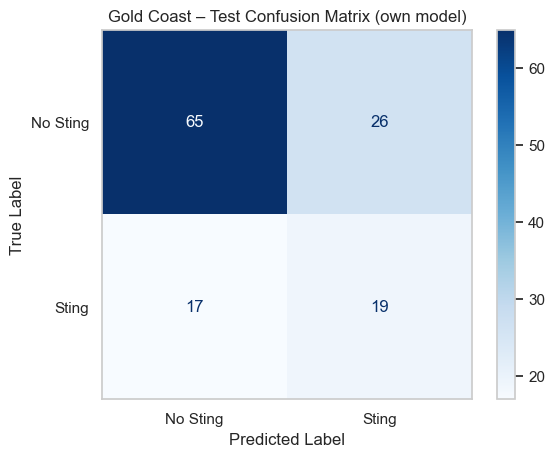

TN: 65  FP: 26  FN: 17  TP: 19
Precision: 0.422  Recall: 0.528  F1: 0.469
Percentages — TN: 51.2%  FP: 20.5%  FN: 13.4%  TP: 15.0%



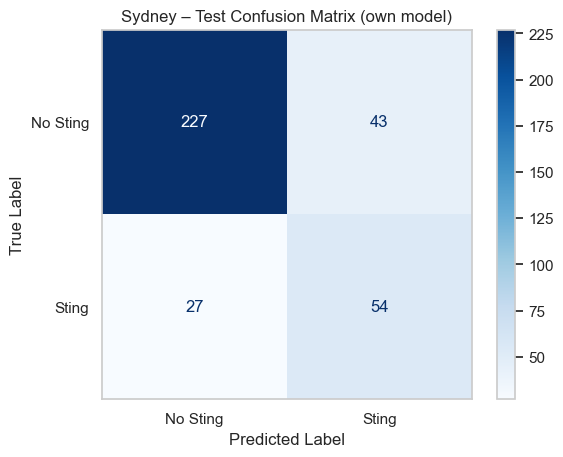

TN: 227  FP: 43  FN: 27  TP: 54
Precision: 0.557  Recall: 0.667  F1: 0.607
Percentages — TN: 64.7%  FP: 12.3%  FN: 7.7%  TP: 15.4%



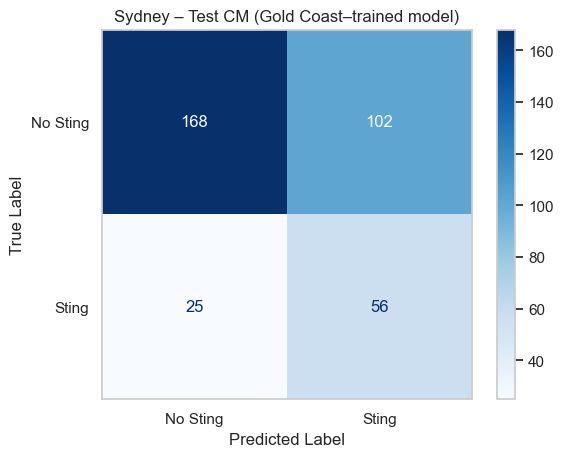

TN: 168  FP: 102  FN: 25  TP: 56
Precision: 0.354  Recall: 0.691  F1: 0.469
Percentages — TN: 47.9%  FP: 29.1%  FN: 7.1%  TP: 16.0%



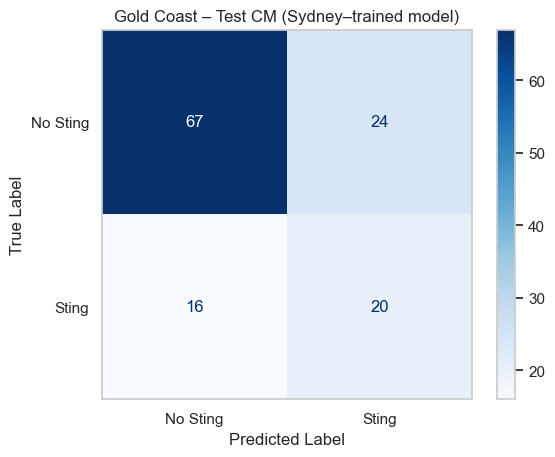

TN: 67  FP: 24  FN: 16  TP: 20
Precision: 0.455  Recall: 0.556  F1: 0.500
Percentages — TN: 52.8%  FP: 18.9%  FN: 12.6%  TP: 15.7%



In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Use tuned thresholds from training cell to derive y_hat from y_prob

def plot_cm(y_true, y_hat, title):
    cm = confusion_matrix(y_true, y_hat)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Sting", "Sting"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.grid(False)
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = (2 * precision * recall) / (precision + recall + 1e-9)

    total = tn + fp + fn + tp
    print(f"TN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")
    print(f"Precision: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}")
    print(f"Percentages — TN: {tn/total*100:.1f}%  FP: {fp/total*100:.1f}%  FN: {fn/total*100:.1f}%  TP: {tp/total*100:.1f}%\n")

# Overall test confusion matrices with tuned thresholds
# In-region CMs
y_hat_gc_test = (y_prob_gc_test >= th_gc).astype(int)
y_hat_sy_test = (y_prob_sy_test >= th_sy).astype(int)
plot_cm(y_true_gc_test, y_hat_gc_test, "Gold Coast – Test Confusion Matrix (own model)")
plot_cm(y_true_sy_test, y_hat_sy_test, "Sydney – Test Confusion Matrix (own model)")

# Cross-region CMs
y_hat_sy_from_gc = (y_prob_sy_test_from_gc >= th_gc).astype(int)
plot_cm(y_true_sy_test, y_hat_sy_from_gc,
        "Sydney – Test CM (Gold Coast–trained model)")

y_hat_gc_from_sy = (y_prob_gc_test_from_sy >= th_sy).astype(int)
plot_cm(y_true_gc_test, y_hat_gc_from_sy,
        "Gold Coast – Test CM (Sydney–trained model)")



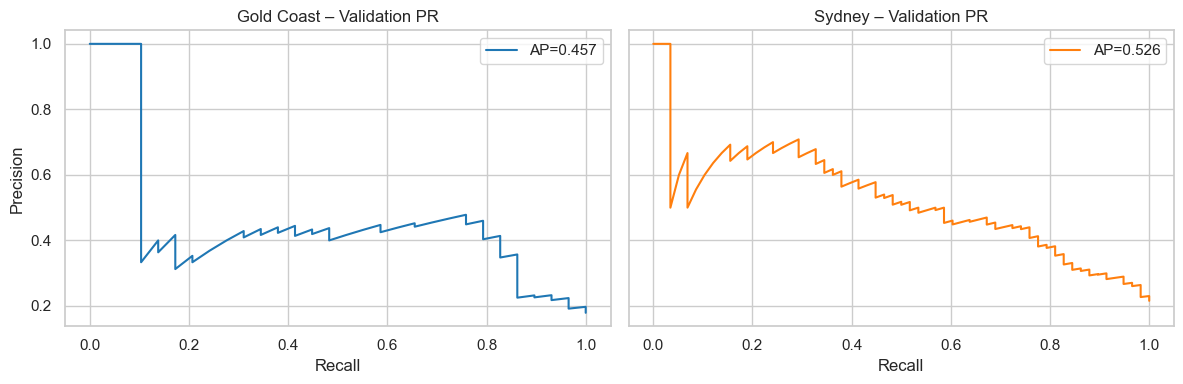

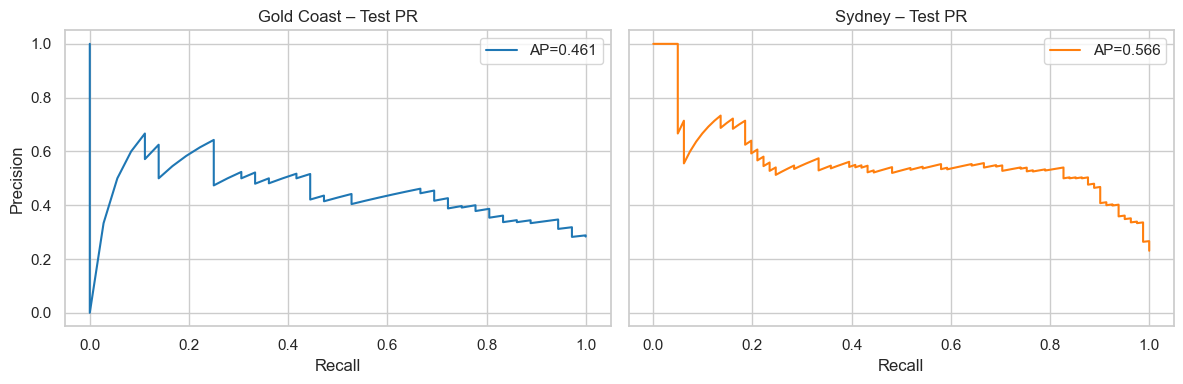

In [67]:
# Precision-Recall curves and Average Precision (PR-AUC)
from sklearn.metrics import precision_recall_curve, average_precision_score

# Validation PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

# Gold Coast (val)
prec_gc_v, rec_gc_v, _ = precision_recall_curve(y_true_gc_val, y_prob_gc_val)
ap_gc_v = average_precision_score(y_true_gc_val, y_prob_gc_val)
axes[0].plot(rec_gc_v, prec_gc_v, color="tab:blue", label=f"AP={ap_gc_v:.3f}")
axes[0].set_title("Gold Coast – Validation PR")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].legend()

# Sydney (val)
prec_sy_v, rec_sy_v, _ = precision_recall_curve(y_true_sy_val, y_prob_sy_val)
ap_sy_v = average_precision_score(y_true_sy_val, y_prob_sy_val)
axes[1].plot(rec_sy_v, prec_sy_v, color="tab:orange", label=f"AP={ap_sy_v:.3f}")
axes[1].set_title("Sydney – Validation PR")
axes[1].set_xlabel("Recall")
axes[1].legend()

plt.tight_layout(); plt.show()

# Test PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

# Gold Coast (test)
prec_gc_t, rec_gc_t, _ = precision_recall_curve(y_true_gc_test, y_prob_gc_test)
ap_gc_t = average_precision_score(y_true_gc_test, y_prob_gc_test)
axes[0].plot(rec_gc_t, prec_gc_t, color="tab:blue", label=f"AP={ap_gc_t:.3f}")
axes[0].set_title("Gold Coast – Test PR")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].legend()

# Sydney (test)
prec_sy_t, rec_sy_t, _ = precision_recall_curve(y_true_sy_test, y_prob_sy_test)
ap_sy_t = average_precision_score(y_true_sy_test, y_prob_sy_test)
axes[1].plot(rec_sy_t, prec_sy_t, color="tab:orange", label=f"AP={ap_sy_t:.3f}")
axes[1].set_title("Sydney – Test PR")
axes[1].set_xlabel("Recall")
axes[1].legend()

plt.tight_layout(); plt.show()
